# Other Tricks

This tutorial covers utility functions and lesser-known features of
ComplexHeatmap that are useful for data manipulation, color customization,
global options, and text measurement:

- `pindex`: parallel indexing into a matrix
- `restore_matrix`: reconstruct a matrix from coordinate + value vectors
- `list_to_matrix`: convert a dict of sets into a binary membership matrix
- `color_ramp2`, `add_transparency`, `rand_color`: color utilities
- `ht_opt` / `reset_ht_opt`: global heatmap options
- `max_text_width` / `max_text_height`: measure text dimensions

In [17]:
import numpy as np
import pandas as pd
import complexheatmap as ch
from complexheatmap import *
import grid_py as gp

## `pindex`: Parallel indexing

`pindex(mat, row_indices, col_indices)` extracts elements from a matrix
using parallel row and column index vectors. This is equivalent to
`mat[row_indices[i], col_indices[i]]` for each `i`.

This is particularly useful in `layer_fun` where you need to extract
original matrix values using vectorized row/column indices.

In [18]:
mat = np.arange(20).reshape(4, 5)
print("Matrix:")
print(mat)

# Extract diagonal elements
result = pindex(mat, np.array([0, 1, 2, 3]), np.array([0, 1, 2, 3]))
expected = np.array([0, 6, 12, 18])
print(f"\nDiagonal: {result}")
print(f"Expected: {expected}")
print(f"Match: {np.array_equal(result, expected)}")

Matrix:
[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]]

Diagonal: [ 0  6 12 18]
Expected: [ 0  6 12 18]
Match: True


In [19]:
# Arbitrary indexing
result2 = pindex(mat, np.array([0, 0, 3]), np.array([0, 4, 2]))
expected2 = np.array([0, 4, 17])
print(f"Arbitrary indices: {result2}")
print(f"Expected:          {expected2}")
print(f"Match: {np.array_equal(result2, expected2)}")

Arbitrary indices: [ 0  4 17]
Expected:          [ 0  4 17]
Match: True


## `restore_matrix`: Reconstruct a matrix from coordinates

Given column indices `j`, row indices `i`, x-coordinates, and y-values,
`restore_matrix` reconstructs the original matrix. This is useful in
`layer_fun` to recover the full matrix from the vectorized inputs.

In [20]:
j = np.array([0, 0, 1, 1])
i = np.array([0, 1, 0, 1])
x = np.array([10.0, 20.0, 30.0, 40.0])
y = np.array([100.0, 200.0, 300.0, 400.0])

result = restore_matrix(j, i, x, y)
expected = np.array([[100.0, 300.0], [200.0, 400.0]])

print(f"Restored matrix:\n{result}")
print(f"Expected:\n{expected}")
print(f"Match: {np.allclose(result, expected)}")

Restored matrix:
[[100. 300.]
 [200. 400.]]
Expected:
[[100. 300.]
 [200. 400.]]
Match: True


## `list_to_matrix`: Convert sets to binary matrix

Given a dict mapping set names to their members, `list_to_matrix` creates
a binary matrix where rows are elements and columns are sets. A value of 1
means the element belongs to that set.

This is useful for preparing input to `make_comb_mat` (UpSet plots) or
for general set-membership visualization.

In [21]:
lt = {"a": {"x", "y", "z"}, "b": {"y", "z", "w"}}
mat_out, row_names, col_names = list_to_matrix(lt)

print(f"Matrix shape: {mat_out.shape}")
print(f"Row names (elements): {row_names}")
print(f"Col names (sets):     {col_names}")
print(f"Matrix:\n{mat_out}")

Matrix shape: (4, 2)
Row names (elements): ['w', 'x', 'y', 'z']
Col names (sets):     ['a', 'b']
Matrix:
[[0 1]
 [1 0]
 [1 1]
 [1 1]]


In [22]:
# Verify membership correctness
y_idx = row_names.index("y")
a_idx = col_names.index("a")
b_idx = col_names.index("b")
w_idx = row_names.index("w")

print(f"'y' in 'a': {mat_out[y_idx, a_idx] == 1}")
print(f"'y' in 'b': {mat_out[y_idx, b_idx] == 1}")
print(f"'w' in 'a': {mat_out[w_idx, a_idx] == 0} (should be absent)")
print(f"'w' in 'b': {mat_out[w_idx, b_idx] == 1}")

'y' in 'a': True
'y' in 'b': True
'w' in 'a': True (should be absent)
'w' in 'b': True


## `color_ramp2`: Color interpolation in LAB space

`color_ramp2` creates a function that maps numeric values to hex colors
by interpolating in CIE-LAB color space. This ensures perceptually
uniform color transitions.

In [23]:
col_fun = color_ramp2([0, 1], ["white", "red"])

c0 = col_fun(0)
c_mid = col_fun(0.5)
c1 = col_fun(1)

print(f"col_fun(0)   = {c0}  (should be #FFFFFF)")
print(f"col_fun(0.5) = {c_mid}  (intermediate)")
print(f"col_fun(1)   = {c1}  (should be #FF0000)")
print(f"Midpoint is interpolated: {c_mid.upper() not in ('#FFFFFF', '#FF0000')}")

col_fun(0)   = #FFFFFF  (should be #FFFFFF)
col_fun(0.5) = #FF9E81  (intermediate)
col_fun(1)   = #FF0000  (should be #FF0000)
Midpoint is interpolated: True


## Vectorized color mapping

The color function can also accept numpy arrays, returning a list of
hex color strings.

In [24]:
col_fun_div = color_ramp2([-1, 0, 1], ["blue", "white", "red"])
colors = col_fun_div(np.array([-1.0, -0.5, 0.0, 0.5, 1.0]))

print(f"Type: {type(colors).__name__}")
print(f"Length: {len(colors)}")
for v, c in zip([-1, -0.5, 0, 0.5, 1], colors):
    print(f"  {v:5.1f} -> {c}")

Type: list
Length: 5
   -1.0 -> #0000FF
   -0.5 -> #B38BFF
    0.0 -> #FFFFFF
    0.5 -> #FF9E81
    1.0 -> #FF0000


## `add_transparency`: Add alpha to colors

Takes a color name or hex and a transparency value (0 = opaque, 1 = fully
transparent) and returns a hex color with alpha channel.

In [25]:
result = add_transparency("red", 0.5)
print(f"red + 0.5 transparency = {result}")

red + 0.5 transparency = #FF000080


## `rand_color`: Generate random colors

Useful for quickly assigning distinct colors to categories.

In [26]:
colors = rand_color(5)
print(f"5 random colors: {colors}")
print(f"Count correct: {len(colors) == 5}")

5 random colors: ['#8E4CAE', '#45BD19', '#8A9B55', '#BF6564', '#A37D11']
Count correct: True


## `ht_opt` and `reset_ht_opt`: Global options

`ht_opt` is a global option object that controls default heatmap behavior.
You can set options like `TITLE_PADDING`, `HEATMAP_LEGEND_PADDING`,
font parameters, etc. Use `reset_ht_opt()` to restore defaults.

In [27]:
print(f"ht_opt exists: {ht_opt is not None}")
print(f"reset_ht_opt callable: {callable(reset_ht_opt)}")

ht_opt exists: True
reset_ht_opt callable: True


In [28]:
# Example: set and reset global options
# ht_opt["HEATMAP_LEGEND_PADDING"] = 5.0
# ... draw heatmaps ...
# reset_ht_opt()  # restore all defaults
print("ht_opt can be used as a dict-like object for global settings.")
print("Always call reset_ht_opt() when done to avoid side effects.")

ht_opt can be used as a dict-like object for global settings.
Always call reset_ht_opt() when done to avoid side effects.


## `max_text_width` and `max_text_height`

These utility functions measure the maximum width/height of a set of text
strings under given graphic parameters. This is useful for calculating
annotation widths to ensure text fits.

In [29]:
texts = ["short", "a medium label", "a rather long text label"]

w = max_text_width(texts)
h = max_text_height(texts)
print(f"Max text width:  {w}")
print(f"Max text height: {h}")

Max text width:  1.0strwidth('short'), 1.0strwidth('a medium label'), 1.0strwidth('a rather long text label')
Max text height: 1.0strheight('short'), 1.0strheight('a medium label'), 1.0strheight('a rather long text label')


## Using `max_text_width` for annotation sizing

A practical pattern: measure the widest gene name and use it to set
the width of a text annotation.

In [30]:
gene_names = [f"GENE_{i}" for i in range(20)]
w = max_text_width(gene_names)
print(f"Width needed for gene names: {w}")

Width needed for gene names: 1.0strwidth('GENE_0'), 1.0strwidth('GENE_1'), 1.0strwidth('GENE_2'), 1.0strwidth('GENE_3'), 1.0strwidth('GENE_4'), 1.0strwidth('GENE_5'), 1.0strwidth('GENE_6'), 1.0strwidth('GENE_7'), 1.0strwidth('GENE_8'), 1.0strwidth('GENE_9'), 1.0strwidth('GENE_10'), 1.0strwidth('GENE_11'), 1.0strwidth('GENE_12'), 1.0strwidth('GENE_13'), 1.0strwidth('GENE_14'), 1.0strwidth('GENE_15'), 1.0strwidth('GENE_16'), 1.0strwidth('GENE_17'), 1.0strwidth('GENE_18'), 1.0strwidth('GENE_19')


## Using color tricks with heatmaps

Combining `color_ramp2` with `add_transparency` allows subtle overlay
effects.

In [31]:
col_fun = color_ramp2([-2, 0, 2], ["blue", "white", "red"])

# Verify boundary colors
print(f"col_fun(-2) = {col_fun(-2)}")
print(f"col_fun(0)  = {col_fun(0)}")
print(f"col_fun(2)  = {col_fun(2)}")

# Add transparency
semi_red = add_transparency("red", 0.3)
semi_blue = add_transparency("blue", 0.7)
print(f"Semi-transparent red:  {semi_red}")
print(f"Semi-transparent blue: {semi_blue}")

col_fun(-2) = #0000FF
col_fun(0)  = #FFFFFF
col_fun(2)  = #FF0000
Semi-transparent red:  #FF0000B2
Semi-transparent blue: #0000FF4D


## Putting it together: a heatmap with all the tricks

Here we combine several utilities in a single heatmap.

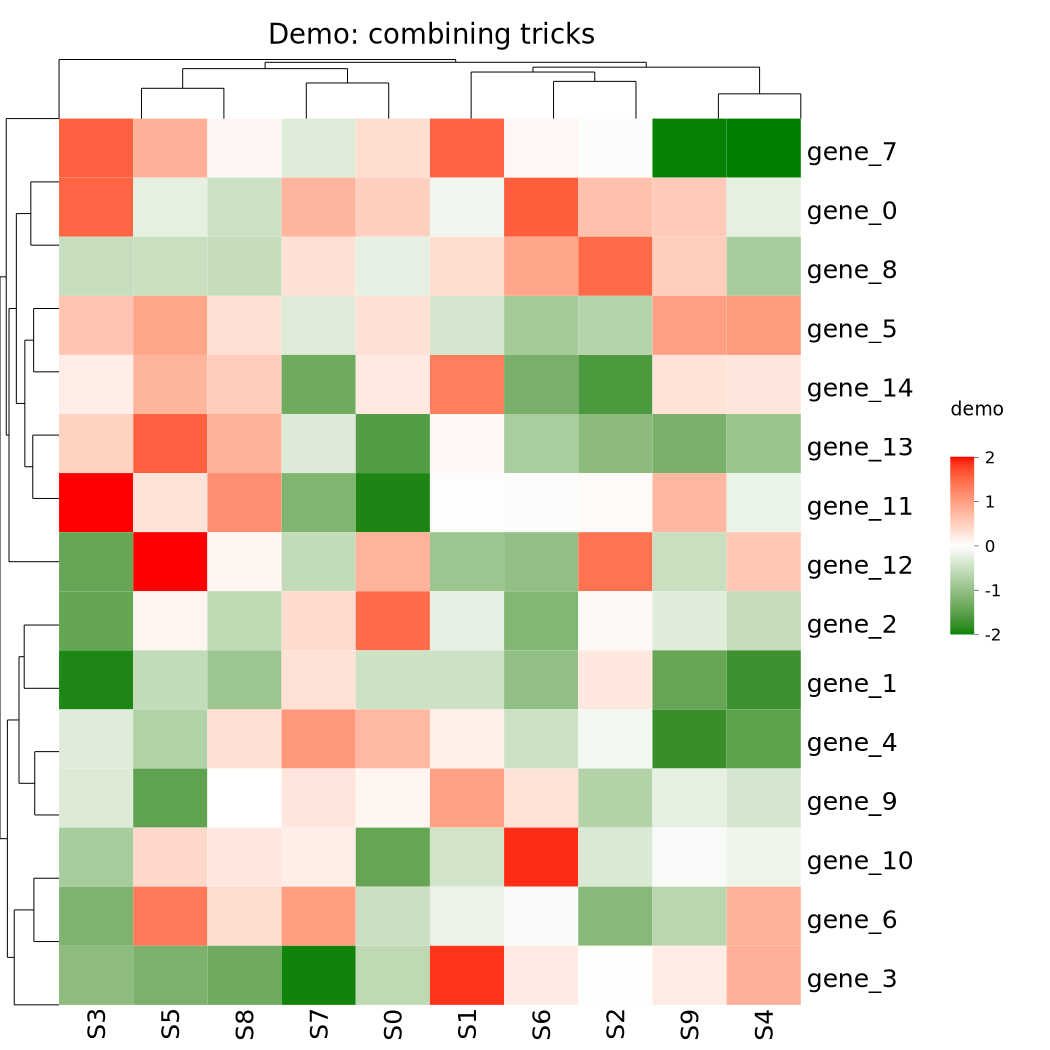

In [32]:
np.random.seed(42)
demo_mat = np.random.randn(15, 10)

col_fun = color_ramp2([-2, 0, 2], ["green", "white", "red"])

ht = Heatmap(
    demo_mat,
    name="demo",
    col=col_fun,
    row_labels=[f"gene_{i}" for i in range(15)],
    column_labels=[f"S{j}" for j in range(10)],
    column_title="Demo: combining tricks",
)
ht.draw()

## Summary

This tutorial covered the utility functions and configuration tools:

- **`pindex`**: parallel indexing for extracting matrix elements by coordinate vectors
- **`restore_matrix`**: reconstruct a matrix from flattened coordinate + value inputs
- **`list_to_matrix`**: convert dict-of-sets to binary membership matrix
- **`color_ramp2`**: LAB-space color interpolation (scalar and vectorized)
- **`add_transparency`**: add alpha channel to colors
- **`rand_color`**: generate random hex colors
- **`ht_opt` / `reset_ht_opt`**: global heatmap configuration
- **`max_text_width` / `max_text_height`**: measure text dimensions for layout